# pPython Tutorial Using LLSC Jupyter Notebook
Version: July 1, 2026
<br>This Jupyter notebook demonstrates how to run pPython examples with different run time modes with LLGrid<br>


# Running Examples from a LLSC System

## Review files in the "Mandelbrot" example directory

In [1]:
import os
HOME = os.getenv('HOME')
EXAMPLE_PATH=os.path.join(HOME,'ppython_tutorial_example/examples/Mandelbrot')
#print('%s'%(EXAMPLE_PATH))
os.chdir(EXAMPLE_PATH)
os.listdir()

['pMandelbrot.py',
 'RUN.py',
 'PythonMPI',
 'mandelbrot_1_4.png',
 'RUN_on_src.py']

### Chgose RUN.py or RUN_on_src.py depedning on your pPython installation type
<strong>RUN.py: script to run the example from a pPython package installation</strong><br>
<strong>RUN_on_script.py: script to run the example from a pPython source installation (no longer supported)</strong>


In [2]:
# Display RUN.py script, whcih demonstrates various job launch scenarios
f = open("RUN.py", "r")
print(f.read())
f.close()

"""RUN.py

    Example script to run a pPython code
    To run, execute the following command.

    python RUN.py

    Author: Dr. Chansup Byun
"""

import pPython
from pRUN import pRUN

# pPython script filename
py_file = 'pMandelbrot.py'
# Define number of MPI processes
n_proc = 4
n_proc_triples = [4,2,24]

# Launch pPython
# print('Running: %s via pRUN().'%(py_file))

run_locally = 0
if run_locally:
    # Running locally
    pRUN( py_file, n_proc, {})
else:
    # Running on a grid environment if configured properly
    # Use the triples mode job
    GRID_TARGET = 'grid-xeon-e5&'
    pRUN( py_file, n_proc_triples, GRID_TARGET )

########################################################
# pPython: Parallel Python Programming Tool
# Dr. Jeremy Kepner and Dr. Chansup Byun
# (kepner@ll.mit.edu and cbyun@ll.mit.edu)
# MIT Lincoln Laboratory
########################################################
# Copyright (c) 2023, Massachusetts Institute of Technology All rights
# reserved.
#
# Redistr

### Interactive jobs

#### Old style

 
Running: pMandelbrot.py
... scancel 1126157
Launching MPI rank: 3 on grid_slurm_3.
Launching MPI rank: 2 on grid_slurm_2.
Launching MPI rank: 1 on grid_slurm_1.
Launching MPI rank: 0 on d-7-1-2.

Submitted batch job 1126328

grid_run: executing pMandelbrot.py in the current python process.
 
Compute Time (sec)                 = 0.028833
Launch+Comm Time (sec)             = 5.250361


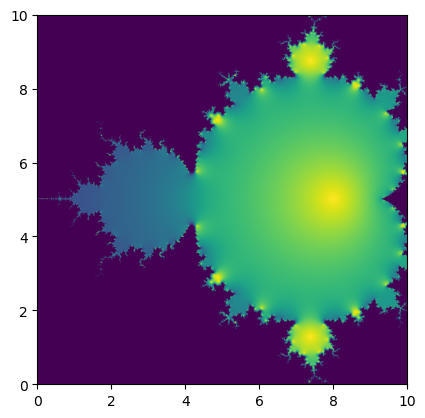



SUCCESS




In [3]:
# Import PythonMPI launch funciton
import pPython
from pRUN import *

# Disable HDF5 file locking (Lustre parallel filesystem on LLSC)
os.environ["HDF5_USE_FILE_LOCKING"]="FALSE"

# By default, local filesystem based messaging kernel is enabled.
# For interactive job, disable it.
os.environ['PPYTHON_LOCAL_FS'] = 'no'
# old styple: does not support central file system -> need to fix this

# PythonMPI script filename
py_file = 'pMandelbrot.py'
# Define number of MPI processes
n_proc = 4

# Launch pPython
pRUN( py_file, n_proc, 'grid-xeon-p8' )

#### Triples mode
<strong>Show only needed changes from the previous old style run</strong>

Running: pMandelbrot.py
... scancel 1126328
Launching MPI rank: 7 to 6 on grid_slurm_4.
Launching MPI rank: 5 to 4 on grid_slurm_3.
Launching MPI rank: 3 to 2 on grid_slurm_2.
Launching MPI rank: 1 to 1 on grid_slurm_1.
Launching MPI rank: 0 to 0 on d-7-1-2.

Submitted batch job 1126331

grid_run: executing pMandelbrot.py in the current python process.
 
Time for the host-to-rank map with TMPDIR (sec): 6.011
Compute Time (sec)                 = 0.009769
Launch+Comm Time (sec)             = 8.568109


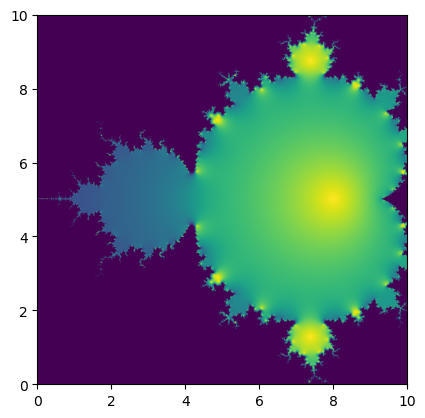



SUCCESS




In [4]:
# Define the triples mode parameters: [nnode, nppn, ntpp]
# nnode: number of compute nodes
# nppn:  number of pPython processes on each compute node
# ntpp:  number of threads per process

n_proc_triples = [4,2,24]

# Launch pPython
# The following environment variable is required for interactive triples modes.
# os.environ['PPYTHON_LOCAL_FS'] = 'yes'

pRUN( py_file, n_proc_triples, 'grid-xeon-p8' )

### Backgrounded jobs

#### Old style

In [6]:
print(os.getcwd())

/home/gridsan/cbyun/ppython_tutorial_example/examples/Mandelbrot


In [7]:
# Launch pPython with '&' after grid
os.environ['PPYTHON_LOCAL_FS'] = 'yes'

# PythonMPI script filename
py_file = 'pMandelbrot.py'
# Define number of MPI processes
n_proc = 4

# Launch pPython
pRUN( py_file, n_proc, 'grid&' )

Running: pMandelbrot.py
... scancel 1126331
Launching MPI rank: 3 on grid_slurm_4.
Launching MPI rank: 2 on grid_slurm_3.
Launching MPI rank: 1 on grid_slurm_2.
Launching MPI rank: 0 on grid_slurm_1.

Submitted batch job 1126335



In [8]:
# Check the PythonMPI subdirectory, which is automatically created

os.listdir('PythonMPI')

['Unix_Commands.2.sh',
 'PythonMPIdefs2.py',
 'pMandelbrot.1.out',
 'pRUN.err',
 'pid.slurm.1126335',
 'PythonMPIdefs3.py',
 'pRUN.log',
 'Unix_Commands.3.sh',
 'PythonMPIdefs1.py',
 'MPI_COMM_WORLD.pkl',
 'Unix_Commands.1.sh',
 'pMandelbrot.2.out',
 'SLURM2HOSTMAP_lock.pkl',
 'SLURM2HOSTMAP.pkl',
 'Unix_Commands.sh',
 'PythonMPIdefs0.py',
 'Unix_Commands.4.sh',
 'pMandelbrot.0.out',
 'pMandelbrot.3.out']

In [9]:
#Check the standard output from the leader process (Pid = 0)

f = open("PythonMPI"+os.sep+"pMandelbrot.0.out", "r")
print(f.read())
f.close()

Time for the host-to-rank map with TMPDIR (sec): 0.045
Compute Time (sec)                 = 0.034726
Launch+Comm Time (sec)             = 6.098842
Figure(640x480)


SUCCESS





#### Triples mode: array job
<strong>Immediate launch as an array job when the requested resources are available</strong><br>
<strong>Show only needed changes from the previous old style run</strong>

In [10]:
os.environ['PPYTHON_LOCAL_FS'] = 'no'

# Define number of MPI processes
n_proc_triples = [4,2,24]

# Launch pPython
pRUN( py_file, n_proc_triples, 'grid-xeon-p8&' )

Running: pMandelbrot.py
... scancel 1126335
Launching MPI rank: 7 to 6 on grid_slurm_4.
Launching MPI rank: 5 to 4 on grid_slurm_3.
Launching MPI rank: 3 to 2 on grid_slurm_2.
Launching MPI rank: 1 to 0 on grid_slurm_1.

Submitted batch job 1126339



In [11]:
# Check the PythonMPI subdirectory, which is automatically created

os.listdir('PythonMPI')

['Unix_Commands.2.sh',
 'pRUN.err',
 'pid.slurm.1126339',
 'pRUN.log',
 'Unix_Commands.3.sh',
 'MPI_COMM_WORLD.pkl',
 'Unix_Commands.1.sh',
 'SLURM2HOSTMAP_lock.pkl',
 'p6-p7_d-19-2-4',
 'SLURM2HOSTMAP.pkl',
 'p4-p5_d-19-3-1',
 'p0-p1_d-19-3-3',
 'Unix_Commands.sh',
 'PythonMPIdefs.py',
 'p2-p3_d-19-3-2',
 'Unix_Commands.4.sh']

In [12]:
#Check the standard output from the leader process (Pid = 0)
my_list = os.listdir('PythonMPI')
for entry in my_list:
    if re.search('p0-',entry):
        #Find the subdirectory for the first compute node 
        subdir_name = entry
        break
#
my_list = os.listdir('PythonMPI')
pidstr = '0'
std_output_file = 'PythonMPI'+os.sep+subdir_name+os.sep+'pMandelbrot.'+pidstr+'.out'
print('Read file, %s'%(std_output_file))
print('')
f = open(std_output_file, "r")
print(f.read())
f.close()

Read file, PythonMPI/p0-p1_d-19-3-3/pMandelbrot.0.out

Time for the host-to-rank map with TMPDIR (sec): 0.053
Compute Time (sec)                 = 0.012525
Launch+Comm Time (sec)             = 11.431589
Figure(640x480)


SUCCESS



